In [1]:
#This file contains the code used for the multiclass case.
#This is a general file in which I computed multiple things.
#Here I computed the preprocessing, pca reduction and made a few confidence and accuracy plots with logistics regression with different pca components.
#There are a few plots in this file that I have not used in the thesis, since I believed it did not add enough value. 

In [2]:
#Data read out and defining the variables:
import scipy.io
data = scipy.io.loadmat('210921.mat')

spks = data['spks']
tc = data['tc']
cue = data['cueAng']
cueIdx = data['cueAngIdx']
corr = data['isCorr']

#Here I selected the correct trials only and .flatten was needed since the dimension need to match.
corr = corr.flatten()
cueIdx = cueIdx.flatten()
corr_bool = corr == 1

#Only keeping the correct trials:
spks = spks[corr_bool]
cueIdx = cueIdx[corr_bool]


In [3]:
y = cueIdx.astype(int)

In [9]:
#Here the boxcar smoothing and downsampling are done.
#I have done this in another way for the multiclass case because the kernel kept dying if I first smoothed it fully and then downsampled it. 
#Here it is immediately downsampled after the smoothing and only that is stored.
import numpy as np
n_trials, n_time_raw, n_neurons = spks.shape

window_ms = 100 #For the smoothing 100ms
sample_step = 10 #For downsampling 10ms

#Defining the kernel:
boxcar_kernel = np.ones(window_ms, dtype=float) / window_ms

# Number of time points after downsampling.
n_time_down = len(np.arange(0, n_time_raw, sample_step))

#List to input the smooth data to:
spks_smooth = np.zeros((n_trials, n_time_down, n_neurons), dtype=float)


#Looping over trials and neurons and then convolving over time to get a smooth representation.
for trial in range(n_trials):
    for neuron in range(n_neurons):

        smoothed = np.convolve(spks[trial, :, neuron],boxcar_kernel,mode="same")
        # Sample every 10 ms
        spks_smooth[trial, :, neuron] = smoothed[::sample_step]


In [10]:
#Calculate z-score.
#List to store the scores:
z_score = np.zeros_like(spks_smooth)

#Loop over each timepoint and then computing the z-score formula:
for t in range(spks_smooth.shape[1]):
    mean = spks_smooth[:, t, :].mean(axis=0)
    std = spks_smooth[:, t, :].std(axis=0)
    z_score[:, t, :] = (spks_smooth[:, t, :] - mean) / (std + 1e-10) #1e-10 was needed to avoid division by 0.



In [13]:
#Here I used logistic regression to obtain the confidence. Note: this is not the accuracy-score. 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
n_trials = spks_smooth.shape[0]
n_time = spks_smooth.shape[1]

#List to store the confidence
confidence = np.full((n_trials, n_time), np.nan)

#Loop over time to obtain the confidence for each time point.
for t in range(n_time):

    X_t = z_score[:, t, :]

    #train_test_split funtion was used here. Stratify was used to make sure that the train and test data were evenly distributed with the classes.
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X_t, y, np.arange(n_trials), test_size=0.3, stratify=y, random_state=0)

    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)

    #This loop maps each prediction back to its correct trial position, since train_test_split predicts multiple test trials at once.
    for j, trial_index in enumerate(idx_test):
        class_index = np.where(model.classes_ == y_test[j])[0][0]
        confidence[trial_index, t] = y_pred[j, class_index]
        

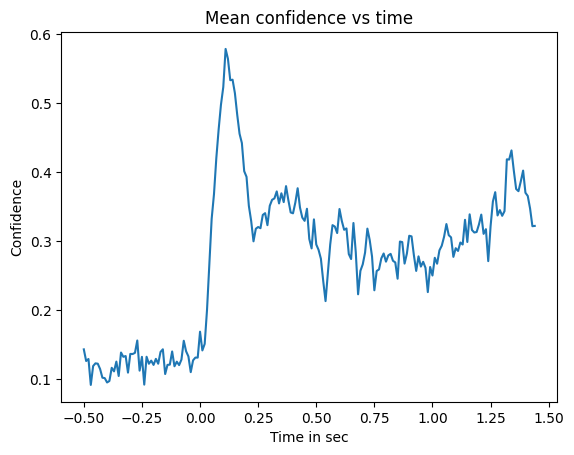

In [15]:
#Plotting the confidence from above
import matplotlib.pyplot as plt
dt = 0.01   
time = -0.5 + np.arange(spks_smooth.shape[1]) * dt

plt.figure()
plt.plot(time, np.nanmean(confidence, axis=0))
plt.xlabel("Time in sec")
plt.ylabel("Confidence")
plt.title("Mean confidence vs time")
plt.show()

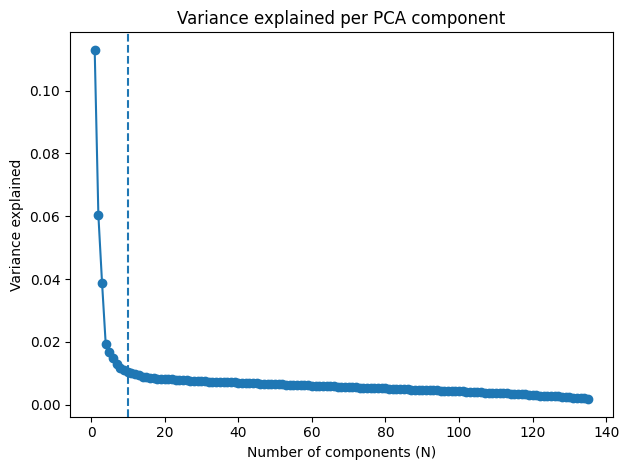

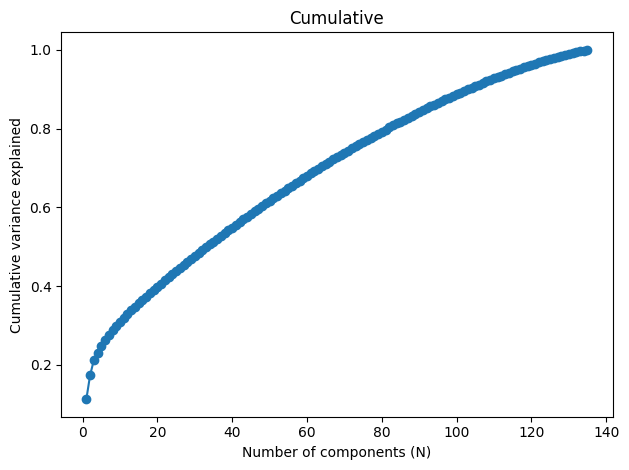

In [19]:
#Here the PCA analysis is done.
from sklearn.decomposition import PCA

#Selecting time period (this is the last preprocessing step).
period = (time >= 0.3) & (time <= 1.4)
X_period = z_score[:, period, :]

n_trials, n_time_period, n_neurons = X_period.shape

X_flat = X_period.reshape(n_trials * n_time_period, n_neurons) #Reshape needed since it has to be 2D for the PCA from sk-learn

pca = PCA()
pca.fit(X_flat)

explained = pca.explained_variance_ratio_ #This gives the variance per pca component

#Plotting the variance per pca component
plt.plot(np.arange(1, len(explained)+1), explained,marker='o')
plt.axvline(x = 10, linestyle='--') #10 PCA line

plt.xlabel("Number of components (N)")
plt.ylabel("Variance explained")
plt.title("Variance explained per PCA component")
plt.tight_layout()
plt.show()


#Plotting the cumaltive variance. This was extra and thus not included in the thesis
cumulative = np.cumsum(explained)

plt.plot(np.arange(1, len(cumulative)+1), cumulative,marker='o')

plt.xlabel("Number of components (N)")
plt.ylabel("Cumulative variance explained")
plt.title("Cumulative")

plt.tight_layout()
plt.show()


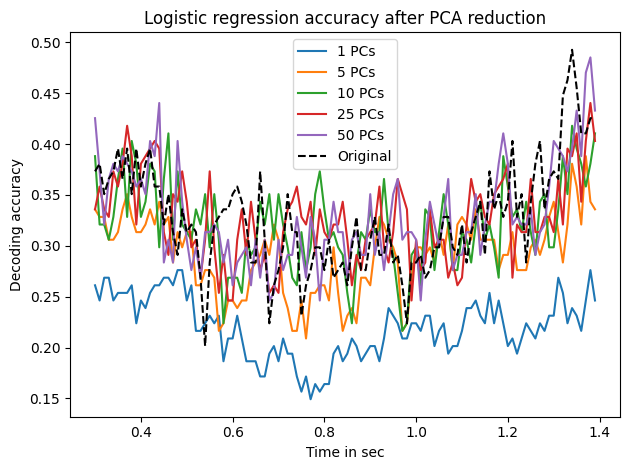

In [21]:
#Here I tested logistic regression with different PCA inputs to see how they differ. This was extra. The code is similar to the code written above, 
#but here I used accuracy instead of confidence.

from sklearn.metrics import accuracy_score
time_period = time[period]

n_trials, n_time_period, n_neurons = X_period.shape

pca_dims = [1, 5, 10, 25, 50]

accuracy_original = np.zeros(n_time_period)
accuracy_by_pca = {}

for t in range(n_time_period):

    X_t = X_period[:, t, :]

    X_train_full, X_test_full, y_train, y_test = train_test_split(X_t, y, test_size=0.3, random_state=0, stratify=y)

    model = LogisticRegression(multi_class='multinomial',solver="lbfgs",max_iter=200)

    model.fit(X_train_full, y_train)

    accuracy_original[t] = accuracy_score(y_test,model.predict(X_test_full)) #This is the accuracy score without pca.

for n in pca_dims:

    accuracies = np.zeros(n_time_period)

    for t in range(n_time_period):

        X_t = X_period[:, t, :]

        X_train_full, X_test_full, y_train, y_test = train_test_split(X_t, y, test_size=0.3, random_state=0, stratify=y)

        pca = PCA(n)
        
        X_train_pca = pca.fit_transform(X_train_full)
        X_test_pca = pca.transform(X_test_full)

        model = LogisticRegression(multi_class='multinomial', solver="lbfgs",max_iter=200)

        model.fit(X_train_pca, y_train)
        accuracies[t] = accuracy_score(y_test,model.predict(X_test_pca)) #This is the accuracy score with pca.

    accuracy_by_pca[n] = accuracies
    
for n in pca_dims:
    plt.plot(time_period, accuracy_by_pca[n], label=f"{n} PCs")

plt.plot(time_period, accuracy_original, linestyle='--', color='black', label="Original")


plt.xlabel("Time in sec")
plt.ylabel("Decoding accuracy")
plt.title("Logistic regression accuracy after PCA reduction")
plt.legend()
plt.tight_layout()
plt.show()

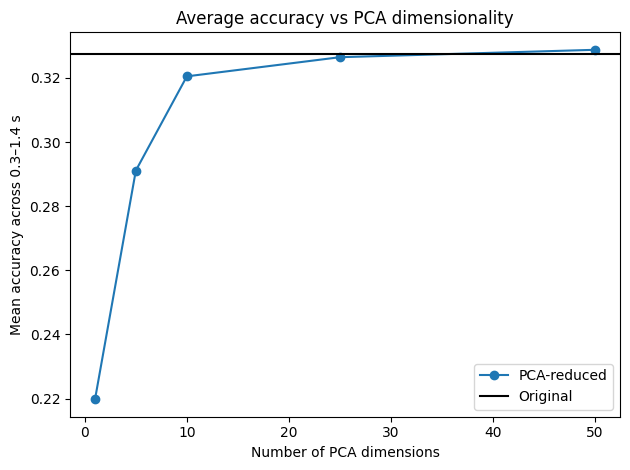

In [22]:
#Average accuracy over time per pca.
mean_accuracy = []

for n in pca_dims:
    mean_accuracy.append(np.mean(accuracy_by_pca[n]))

mean_original = np.mean(accuracy_original)

plt.plot(pca_dims,mean_accuracy,marker='o',label="PCA-reduced")

plt.axhline(mean_original, color='black', label="Original")

plt.xlabel("Number of PCA dimensions")
plt.ylabel("Mean accuracy across 0.3–1.4 s")
plt.title("Average accuracy vs PCA dimensionality")
plt.legend()
plt.tight_layout()
plt.show()

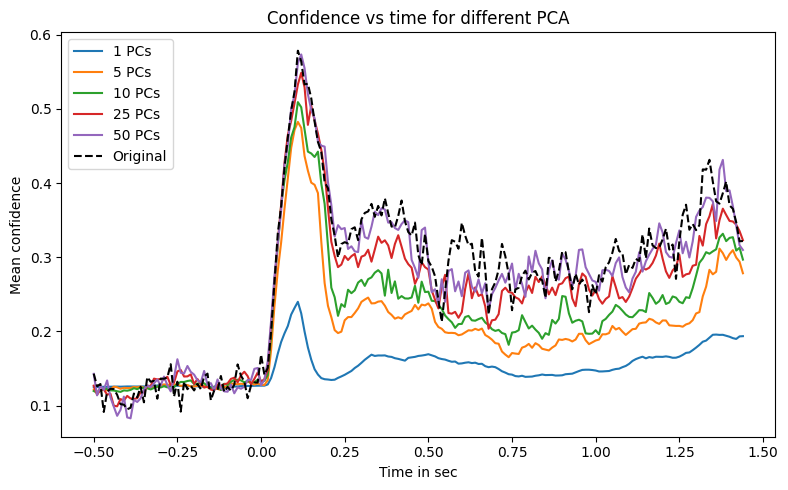

In [24]:
#Same as previous code but this is with the confidence.
pca_dims = [1, 5, 10, 25, 50]

n_trials = spks_smooth.shape[0]
n_time = spks_smooth.shape[1]
confidence_by_pca = {}

for n_pca in pca_dims:

    confidence_pca = np.full((n_trials, n_time), np.nan)

    for t in range(n_time):

        X_t = z_score[:, t, :]  
        X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X_t, y, np.arange(n_trials), test_size=0.3, stratify=y, random_state = 0)

        pca = PCA(n_components=n_pca)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)

        model = LogisticRegression(multi_class='multinomial', solver="lbfgs", max_iter=200)
        model.fit(X_train_pca, y_train)

        y_pred = model.predict_proba(X_test_pca)

        for j, trial_index in enumerate(idx_test):
            class_index = np.where(model.classes_ == y_test[j])[0][0]
            confidence_pca[trial_index, t] = y_pred[j, class_index]

    confidence_by_pca[n_pca] = confidence_pca


for n_pca in pca_dims:
    mean_conf = np.nanmean(confidence_by_pca[n_pca], axis=0)
    plt.plot(time, mean_conf, label=f"{n_pca} PCs")
    
plt.plot(time, np.nanmean(confidence, axis=0), linestyle='--',color='black', label="Original")
plt.xlabel("Time in sec")
plt.ylabel("Mean confidence")
plt.title("Confidence vs time for different PCA")
plt.legend()
plt.tight_layout()
plt.show()